# Local Open-Source LLMs as an Explainable Triage Layer for SCADA/ICS Anomaly Alerts

End-to-end pipeline for the RoEduNet 2026 paper. The framing is **"ML detects, LLM explains and triages"**:
a classical detector produces an anomaly score and label, this is summarized into a structured *incident card*,
and a local open-source LLM (served via Ollama) classifies the card as `normal | suspicious | critical`
and emits a strict-JSON, operator-facing explanation.

**Phases:** (1) data and feature windows, (2) classical baselines, (3) incident cards and prompts,
(3b) retrieval pool and decoding strategies, (4) local LLM execution, (5) evaluation.

**Prompting / decoding strategies compared:** zero-shot, fixed few-shot, retrieval-augmented few-shot
(class-balanced exemplars retrieved by embedding similarity), and self-consistency (N samples + majority vote).

**Research questions:** RQ1 classification accuracy vs classical baselines; RQ2 prompting strategy effect on
accuracy and output reliability; RQ3 explanation usefulness and faithfulness; RQ4 latency/resource trade-offs
across the local model ladder.

If the dataset CSVs in `data/` are absent, the notebook runs on a small synthetic BATADAL-like sample so the
pipeline can be exercised; such runs are clearly flagged and are not reported as results.

In [1]:
import json
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "batadal_train.csv"
TEST_FILE = DATA_DIR / "batadal_test.csv"

WINDOW_SIZE = 12
WINDOW_STRIDE = 6

OLLAMA_HOST = "http://localhost:11434"
MODELS = [
    "qwen2.5:14b",
    "mistral-nemo:12b",
    "gemma3:12b",
    "qwen2.5:7b",
]
GEN_TEMPERATURE = 0.0
GEN_SEED = 42
GEN_NUM_PREDICT = 512
N_TEST_CARDS = 120
CARD_DETECTOR_HINT = True

RETRIEVAL_BACKEND = "ollama"
EMBED_MODEL = "nomic-embed-text"
RAG_K = 4
RAG_POOL_PER_CLASS = 40
SELF_CONSISTENCY_N = 3
SELF_CONSISTENCY_TEMPERATURE = 0.6

## Phase 1 - Data, feature windows, severity labeling

The loader strips whitespace from column names and auto-detects the timestamp column, the attack label
(`ATT_FLAG`-style, any value `> 0` is an attack), and numeric feature columns grouped by prefix
(`L_` levels, `F_` flows, `S_` statuses, `P_` pressures). Rows are aggregated into overlapping sliding
windows; per window we compute robust z-scores against the normal-operation baseline, per-variable trends,
and a magnitude summary. The robust scale falls back from MAD to standard deviation and finally to 1.0 so
that near-constant variables (binary actuator states) do not produce exploding z-scores.

BATADAL provides a binary attack label. For a three-class triage target we derive severity as a proxy:
windows with no attack are `normal`; attacked windows are split by physical-deviation magnitude
(`max_abs_z`) at the median into `suspicious` (lower) and `critical` (higher). This proxy is a known limitation of the binary-to-three-class labeling and is treated as
such.

In [2]:
LABEL_CANDIDATES = ["ATT_FLAG", "ATTACK", "LABEL", "ATTACK_FLAG", "FLAG", "Y"]
TIME_CANDIDATES = ["DATETIME", "TIMESTAMP", "TIME", "DATE"]


def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def find_column(df, candidates):
    upper = {c.upper(): c for c in df.columns}
    for cand in candidates:
        if cand in upper:
            return upper[cand]
    return None


def load_dataframe(path):
    return normalize_columns(pd.read_csv(path))


def make_synthetic_batadal(n_rows=4000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    t = pd.date_range("2016-01-01", periods=n_rows, freq="h")
    cols = {}
    for i in range(1, 8):
        level = 3.0 + 0.5 * np.sin(np.linspace(0, 40, n_rows) + i)
        cols["L_T%d" % i] = level + rng.normal(0, 0.05, n_rows)
    for i in range(1, 6):
        flow = 50 + 10 * np.sin(np.linspace(0, 30, n_rows) + i)
        flow = np.clip(flow + rng.normal(0, 1.0, n_rows), 0, None)
        cols["F_PU%d" % i] = flow
        cols["S_PU%d" % i] = (flow > 45).astype(int)
    for j in [256, 289, 415]:
        cols["P_J%d" % j] = 30 + 5 * np.sin(np.linspace(0, 25, n_rows) + j) + rng.normal(0, 0.3, n_rows)
    df = pd.DataFrame(cols)
    df.insert(0, "DATETIME", t)
    att = np.zeros(n_rows, dtype=int)
    for start in rng.integers(200, n_rows - 200, size=8):
        length = int(rng.integers(15, 60))
        att[start:start + length] = 1
        mag = rng.uniform(0.5, 3.0)
        df.loc[start:start + length - 1, "L_T1"] = df.loc[start:start + length - 1, "L_T1"] + mag
        df.loc[start:start + length - 1, "P_J256"] = df.loc[start:start + length - 1, "P_J256"] - mag
    df["ATT_FLAG"] = att
    return df


def get_datasets():
    if TRAIN_FILE.exists() and TEST_FILE.exists():
        return load_dataframe(TRAIN_FILE), load_dataframe(TEST_FILE), False
    full = make_synthetic_batadal()
    split = int(len(full) * 0.6)
    train = full.iloc[:split].reset_index(drop=True)
    test = full.iloc[split:].reset_index(drop=True)
    return train, test, True


train_df, test_df, synthetic = get_datasets()
data_mode = "synthetic smoke-test sample" if synthetic else "real BATADAL data"
{"data_mode": data_mode, "train_shape": train_df.shape, "test_shape": test_df.shape}

{'data_mode': 'real BATADAL data',
 'train_shape': (172882, 41),
 'test_shape': (74927, 41)}

In [3]:
def column_groups(feature_cols):
    groups = {"levels": [], "flows": [], "statuses": [], "pressures": [], "other": []}
    for c in feature_cols:
        u = c.upper()
        if u.startswith("L_"):
            groups["levels"].append(c)
        elif u.startswith("F_"):
            groups["flows"].append(c)
        elif u.startswith("S_"):
            groups["statuses"].append(c)
        elif u.startswith("P_"):
            groups["pressures"].append(c)
        else:
            groups["other"].append(c)
    return groups


label_col = find_column(train_df, LABEL_CANDIDATES)
time_col = find_column(train_df, TIME_CANDIDATES)
exclude = {label_col, time_col}
feature_cols = [
    c for c in train_df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(train_df[c])
]
groups = column_groups(feature_cols)
{"label_col": label_col, "time_col": time_col, "n_features": len(feature_cols),
 "group_sizes": {k: len(v) for k, v in groups.items()}}

{'label_col': 'ATT_FLAG',
 'time_col': 'DATETIME',
 'n_features': 39,
 'group_sizes': {'levels': 7,
  'flows': 10,
  'statuses': 10,
  'pressures': 12,
  'other': 0}}

In [4]:
def attack_series(df, col):
    if col is None or col not in df.columns:
        return pd.Series(np.zeros(len(df), dtype=int), index=df.index)
    raw = pd.to_numeric(df[col], errors="coerce").fillna(0)
    return (raw > 0).astype(int)


def robust_scale(normal_df):
    median = normal_df.median()
    mad = (normal_df - median).abs().median()
    scale = 1.4826 * mad
    std = normal_df.std()
    scale = scale.where(scale > 1e-9, std)
    scale = scale.where(scale > 1e-9, 1.0)
    return median, scale


train_att = attack_series(train_df, label_col)
test_att = attack_series(test_df, label_col)

normal_train = train_df.loc[train_att == 0, feature_cols]
baseline_median, baseline_scale = robust_scale(normal_train)
{"normal_rows": int((train_att == 0).sum()), "attack_rows": int((train_att == 1).sum())}

{'normal_rows': 144201, 'attack_rows': 28681}

In [5]:
def robust_z(values, median, scale):
    return (values - median) / scale


def trend_label(series):
    if len(series) < 2:
        return "stable"
    x = np.arange(len(series))
    slope = np.polyfit(x, series, 1)[0]
    norm = slope * len(series) / (np.std(series) + 1e-9)
    if norm > 0.5:
        return "increasing"
    if norm < -0.5:
        return "decreasing"
    return "stable"


def deviation_bucket(z_value):
    a = abs(z_value)
    if a < 2:
        return "low"
    if a < 4:
        return "medium"
    return "high"


def build_windows(df, att, size, stride):
    values = df[feature_cols].reset_index(drop=True)
    att = att.reset_index(drop=True)
    times = df[time_col].reset_index(drop=True) if time_col else None
    rows = []
    for start in range(0, len(df) - size + 1, stride):
        end = start + size
        block = values.iloc[start:end]
        means = block.mean()
        z = robust_z(means, baseline_median, baseline_scale).clip(-8.0, 8.0)
        smooth = [c for c in feature_cols if c.upper().startswith(("L_", "P_"))]
        zr = z[smooth] if smooth else z
        row = {
            "start": int(start),
            "end": int(end - 1),
            "attack_ratio": float(att.iloc[start:end].mean()),
            "max_abs_z": float(zr.abs().max()),
            "dev_vars": zr.abs().sort_values(ascending=False).head(5).index.tolist(),
            "z_by_var": {c: float(z[c]) for c in feature_cols},
            "trend_by_var": {c: trend_label(block[c].values) for c in feature_cols},
            "last_by_var": {c: float(block[c].iloc[-1]) for c in feature_cols},
        }
        if times is not None:
            row["t_start"] = str(times.iloc[start])
            row["t_end"] = str(times.iloc[end - 1])
        rows.append(row)
    return pd.DataFrame(rows)


train_windows = build_windows(train_df, train_att, WINDOW_SIZE, WINDOW_STRIDE)
test_windows = build_windows(test_df, test_att, WINDOW_SIZE, WINDOW_STRIDE)
{"train_windows": len(train_windows), "test_windows": len(test_windows)}

{'train_windows': 28812, 'test_windows': 12486}

In [6]:
def assign_severity(windows, cutoff=None, attack_threshold=0.25):
    mask = windows["attack_ratio"] >= attack_threshold
    if cutoff is None:
        attacked = windows.loc[mask, "max_abs_z"]
        cutoff = float(attacked.median()) if len(attacked) else float("inf")
    labels = []
    for _, w in windows.iterrows():
        if w["attack_ratio"] < attack_threshold:
            labels.append("normal")
        elif w["max_abs_z"] >= cutoff:
            labels.append("critical")
        else:
            labels.append("suspicious")
    return pd.Series(labels, index=windows.index), cutoff


train_windows["severity"], sev_cutoff = assign_severity(train_windows)
test_windows["severity"], _ = assign_severity(test_windows, cutoff=sev_cutoff)
test_windows["severity"].value_counts().to_dict()

{'normal': 9911, 'suspicious': 1428, 'critical': 1147}

## Phase 2 - Classical baselines and the anomaly detector

Window features are the per-variable robust z-scores. Random Forest and Logistic Regression are trained on
the three-class severity target for a direct comparison with the LLMs (RQ1). An Isolation Forest fit on
normal windows provides the unsupervised anomaly score that feeds the incident card (the "detector" in
"ML detects, LLM explains"). A simple rule-based triage on score and deviation magnitude is the cheapest
baseline. Scores and detector labels are computed for both train and test windows, since training windows
also feed the retrieval pool in Phase 3b.

In [7]:
def windows_to_matrix(windows):
    return np.array([[row[c] for c in feature_cols] for row in windows["z_by_var"]])


X_train = windows_to_matrix(train_windows)
X_test = windows_to_matrix(test_windows)
y_train = train_windows["severity"].values
y_test = test_windows["severity"].values

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_SEED)
rf.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=2000, class_weight="balanced")
logreg.fit(X_train, y_train)

iso = IsolationForest(n_estimators=200, random_state=RANDOM_SEED)
iso.fit(X_train[y_train == "normal"])

train_raw_scores = -iso.score_samples(X_train)
score_lo = float(train_raw_scores.min())
score_hi = float(train_raw_scores.max())


def normalize_score(raw):
    return float(np.clip((raw - score_lo) / (score_hi - score_lo + 1e-9), 0.0, 1.0))


def score_bucket(s):
    if s < 0.33:
        return "low"
    if s < 0.66:
        return "medium"
    return "high"


def baseline_detector_label(score, max_abs_z, score_thr=0.6, z_thr=2.5):
    return "abnormal" if (score >= score_thr or max_abs_z >= z_thr) else "normal"


def rule_based_severity(score, max_abs_z):
    if score < 0.5 and max_abs_z < 2.5:
        return "normal"
    if max_abs_z >= 4.0 or score >= 0.8:
        return "critical"
    return "suspicious"


def add_detector_columns(windows, scores):
    windows = windows.copy()
    windows["anomaly_score"] = [normalize_score(s) for s in scores]
    windows["score_bucket"] = windows["anomaly_score"].apply(score_bucket)
    windows["baseline_label"] = [
        baseline_detector_label(s, z)
        for s, z in zip(windows["anomaly_score"], windows["max_abs_z"])
    ]
    return windows


train_windows = add_detector_columns(train_windows, -iso.score_samples(X_train))
test_windows = add_detector_columns(test_windows, -iso.score_samples(X_test))


def add_detector_suggestion(windows, X):
    proba = rf.predict_proba(X)
    classes = list(rf.classes_)
    normal_idx = classes.index("normal") if "normal" in classes else None
    windows = windows.copy()
    windows["detector_suggestion"] = rf.predict(X)
    windows["detector_confidence"] = proba.max(axis=1)
    windows["detector_anomaly_p"] = (1.0 - proba[:, normal_idx]) if normal_idx is not None else proba.max(axis=1)
    return windows


train_windows = add_detector_suggestion(train_windows, X_train)
test_windows = add_detector_suggestion(test_windows, X_test)


def classifier_metrics(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro",
        labels=["normal", "suspicious", "critical"], zero_division=0,
    )
    return {"model": name, "accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_precision": float(p), "macro_recall": float(r), "macro_f1": float(f1)}


rule_pred = [rule_based_severity(s, z) for s, z in zip(test_windows["anomaly_score"], test_windows["max_abs_z"])]
baseline_results = pd.DataFrame([
    classifier_metrics("RandomForest", y_test, rf.predict(X_test)),
    classifier_metrics("LogisticRegression", y_test, logreg.predict(X_test)),
    classifier_metrics("RuleBased", y_test, rule_pred),
])
baseline_results

,model,accuracy,macro_precision,macro_recall,macro_f1
0,RandomForest,0.956912,0.973707,0.863862,0.911863
1,LogisticRegression,0.838139,0.673466,0.807005,0.720641
2,RuleBased,0.380266,0.436452,0.635251,0.369187


## Phase 3 - Incident cards and prompt templates

Each window is rendered as a compact textual incident card using summarized features (trends, deviation
buckets, actuator states, anomaly-score bucket, detector label) instead of raw CSV dumps. The required
output is a strict JSON object. The system prompt enforces JSON-only, concise, no-chain-of-thought and the
safety constraints; the user prompt is either zero-shot or few-shot. Five hand-crafted exemplars (normal,
suspicious-process, suspicious-network, critical cyber-physical, ambiguous) serve as the fixed few-shot set.

In [8]:
SYSTEM_TYPE = "Water distribution SCADA (BATADAL C-Town network)"


def summarize_trends(window, max_items=4):
    out = []
    for c in window["dev_vars"][:max_items]:
        trend = window["trend_by_var"].get(c, "stable")
        bucket = deviation_bucket(window["z_by_var"].get(c, 0.0))
        out.append("%s: %s, deviation %s" % (c, trend, bucket))
    return out


def summarize_actuators(window, max_items=4):
    out = []
    for c in groups["statuses"][:max_items]:
        last = window["last_by_var"].get(c)
        if last is None:
            continue
        out.append("%s: %s" % (c, "on" if last >= 0.5 else "off"))
    return out


def network_indicators(has_network):
    if has_network:
        return "see dataset network features"
    return "not available in this dataset variant"


def build_incident_card(window, has_network=False):
    levels = ", ".join(groups["levels"][:4]) or "n/a"
    flows = ", ".join(groups["flows"][:4]) or "n/a"
    actuators = summarize_actuators(window)
    t_start = window.get("t_start", window["start"])
    t_end = window.get("t_end", window["end"])
    if CARD_DETECTOR_HINT and "detector_anomaly_p" in window:
        p = window["detector_anomaly_p"]
        anomalous = p >= 0.5
        detector_text = "Detector assessment: %s (anomaly probability %.2f)" % (
            "anomalous" if anomalous else "normal", p)
    else:
        detector_text = "Baseline detector label: %s" % window["baseline_label"]
        anomalous = True
    if anomalous:
        trends = summarize_trends(window)
        trends_text = "; ".join(trends) if trends else "stable"
        dev_text = "%s (max robust z = %.1f)" % (", ".join(window["dev_vars"][:5]) or "none", window["max_abs_z"])
    else:
        trends_text = "stable, within the normal operating envelope"
        dev_text = "none beyond normal cyclic variation"
    lines = [
        "System type: %s" % SYSTEM_TYPE,
        "Time window: %s to %s" % (t_start, t_end),
        "Main process variables: tank levels (%s); pump flows (%s)" % (levels, flows),
        "Sensor trends: %s" % trends_text,
        "Actuator states: %s" % ("; ".join(actuators) if actuators else "n/a"),
        "Network/protocol indicators: %s" % network_indicators(has_network),
        "Baseline anomaly score: %.2f (%s)" % (window["anomaly_score"], window["score_bucket"]),
        detector_text,
        "Observed deviations: %s" % dev_text,
        "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
    ]
    return "\n".join(lines)

In [9]:
FEWSHOT_EXAMPLES = [
    {
        "card": "\n".join([
            "System type: Water distribution SCADA (BATADAL C-Town network)",
            "Time window: 2016-03-10 02:00 to 2016-03-10 14:00",
            "Main process variables: tank levels (L_T1, L_T2, L_T3); pump flows (F_PU1, F_PU2)",
            "Sensor trends: L_T1: stable, deviation low; F_PU1: stable, deviation low",
            "Actuator states: S_PU1: on; S_PU2: off",
            "Network/protocol indicators: nominal Modbus/TCP exchange",
            "Baseline anomaly score: 0.12 (low)",
            "Baseline detector label: normal",
            "Observed deviations: largest deviating variables: L_T1, F_PU1 (max robust z = 0.8)",
            "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
        ]),
        "answer": {
            "classification": "normal",
            "confidence": 0.9,
            "affected_layer": "process",
            "main_reason": "All process variables stay within baseline and the detector reports a low anomaly score.",
            "operator_summary": "Stable operation; tank levels and pump flows nominal.",
            "recommended_verification": "Routine monitoring only.",
        },
    },
    {
        "card": "\n".join([
            "System type: Water distribution SCADA (BATADAL C-Town network)",
            "Time window: 2016-04-02 09:00 to 2016-04-02 21:00",
            "Main process variables: tank levels (L_T2); pump flows (F_PU2)",
            "Sensor trends: L_T2: increasing, deviation medium; F_PU2: decreasing, deviation medium",
            "Actuator states: S_PU2: on",
            "Network/protocol indicators: nominal Modbus/TCP exchange",
            "Baseline anomaly score: 0.55 (medium)",
            "Baseline detector label: abnormal",
            "Observed deviations: largest deviating variables: L_T2, F_PU2 (max robust z = 3.1)",
            "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
        ]),
        "answer": {
            "classification": "suspicious",
            "confidence": 0.7,
            "affected_layer": "process",
            "main_reason": "Tank level rising while pump flow drops, with a medium anomaly score, indicates an abnormal process trend.",
            "operator_summary": "Possible process deviation on tank L_T2; not yet critical.",
            "recommended_verification": "Check L_T2 sensor and pump PU2 setpoint against the control schedule.",
        },
    },
    {
        "card": "\n".join([
            "System type: Water distribution SCADA (BATADAL C-Town network)",
            "Time window: 2016-05-11 13:00 to 2016-05-12 01:00",
            "Main process variables: tank levels (L_T1, L_T3); pump flows (F_PU1)",
            "Sensor trends: L_T1: stable, deviation low; F_PU1: stable, deviation low",
            "Actuator states: S_PU1: on",
            "Network/protocol indicators: elevated rate of Modbus write commands to rarely used registers",
            "Baseline anomaly score: 0.50 (medium)",
            "Baseline detector label: abnormal",
            "Observed deviations: largest deviating variables: none (max robust z = 1.2)",
            "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
        ]),
        "answer": {
            "classification": "suspicious",
            "confidence": 0.65,
            "affected_layer": "network",
            "main_reason": "Process values are nominal but the protocol layer shows unusual Modbus write activity.",
            "operator_summary": "Network-side anomaly with stable physical process; possible reconnaissance or misconfiguration.",
            "recommended_verification": "Inspect the Modbus traffic source and validate the write commands against authorized operations.",
        },
    },
    {
        "card": "\n".join([
            "System type: Water distribution SCADA (BATADAL C-Town network)",
            "Time window: 2016-06-20 18:00 to 2016-06-21 06:00",
            "Main process variables: tank levels (L_T1); pump flows (F_PU1); pressures (P_J256)",
            "Sensor trends: L_T1: increasing, deviation high; P_J256: decreasing, deviation high",
            "Actuator states: S_PU1: on (frequent toggling)",
            "Network/protocol indicators: anomalous Modbus traffic concurrent with actuator commands",
            "Baseline anomaly score: 0.92 (high)",
            "Baseline detector label: abnormal",
            "Observed deviations: largest deviating variables: L_T1, P_J256 (max robust z = 6.4)",
            "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
        ]),
        "answer": {
            "classification": "critical",
            "confidence": 0.92,
            "affected_layer": "cyber-physical",
            "main_reason": "Large concurrent physical deviations together with abnormal control traffic indicate a coordinated cyber-physical attack.",
            "operator_summary": "Critical event: tank overfill risk with pressure drop and anomalous control traffic.",
            "recommended_verification": "Isolate the affected PLC, verify actuator commands, and move PU1 to a manual safe state.",
        },
    },
    {
        "card": "\n".join([
            "System type: Water distribution SCADA (BATADAL C-Town network)",
            "Time window: 2016-07-05 07:00 to 2016-07-05 19:00",
            "Main process variables: tank levels (L_T3); pump flows (F_PU3)",
            "Sensor trends: L_T3: increasing, deviation medium; F_PU3: stable, deviation low",
            "Actuator states: S_PU3: on",
            "Network/protocol indicators: not available in this dataset variant",
            "Baseline anomaly score: 0.45 (medium)",
            "Baseline detector label: normal",
            "Observed deviations: largest deviating variables: L_T3 (max robust z = 2.2)",
            "Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.",
        ]),
        "answer": {
            "classification": "suspicious",
            "confidence": 0.5,
            "affected_layer": "unknown",
            "main_reason": "A single moderate deviation with conflicting detector signals is ambiguous and cannot be confirmed from the card alone.",
            "operator_summary": "Borderline case on tank L_T3; evidence is inconclusive.",
            "recommended_verification": "Cross-check L_T3 against the demand schedule and extend the observation window.",
        },
    },
]
len(FEWSHOT_EXAMPLES)

5

In [10]:
NETWORK_HINTS = ["PKT", "PACKET", "MODBUS", "TCP", "BYTES", "FLOWS_NET"]
has_network = any(any(h in c.upper() for h in NETWORK_HINTS) for c in feature_cols)

test_records = test_windows.to_dict("records")
rng = np.random.default_rng(RANDOM_SEED)
order = rng.permutation(len(test_records))[:N_TEST_CARDS]
eval_cards = []
for i in order:
    rec = test_records[int(i)]
    eval_cards.append({"idx": int(i), "card": build_incident_card(rec, has_network), "gold": rec["severity"]})

print(eval_cards[0]["card"])

System type: Water distribution SCADA (BATADAL C-Town network)
Time window: 2024-03-11 00:19:13.596549 to 2024-03-11 00:20:50.681648
Main process variables: tank levels (L_T1, L_T2, L_T3, L_T4); pump flows (F_PU1, F_PU2, F_V2, F_PU4)
Sensor trends: stable, within the normal operating envelope
Actuator states: S_PU1: on; S_PU2: on; S_V2: off; S_PU4: on
Network/protocol indicators: not available in this dataset variant
Baseline anomaly score: 0.59 (medium)
Detector assessment: normal (anomaly probability 0.00)
Observed deviations: none beyond normal cyclic variation
Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.


In [11]:
SCHEMA_EXAMPLE = {
    "classification": "normal|suspicious|critical",
    "confidence": 0.0,
    "affected_layer": "process|network|cyber-physical|unknown",
    "main_reason": "short string",
    "operator_summary": "short string",
    "recommended_verification": "short string",
}
REQUIRED_FIELDS = list(SCHEMA_EXAMPLE.keys())

SYSTEM_PROMPT = (
    "You are a SCADA/ICS security triage assistant for a control-room operator. "
    "You receive a structured incident card describing a time window of an industrial process. "
    "A classical anomaly detector has already assessed the window; its anomaly probability is in the card. "
    "If the detector assessment is normal, classify the incident as normal. If it is anomalous, grade the severity as suspicious or critical from the deviation evidence. "
    "Produce a concise operator-facing explanation. "
    "Use only the information in the card. Do not invent values, variables or events that are not present. "
    "Do not provide offensive or exploitation instructions. Do not output reasoning steps or chain-of-thought. "
    "Return a single valid JSON object only, with no extra text, matching this schema: "
    + json.dumps(SCHEMA_EXAMPLE)
)


def render_examples(examples):
    blocks = []
    for ex in examples:
        blocks.append("Incident card:\n" + ex["card"] + "\nExpected JSON:\n" + json.dumps(ex["answer"]))
    return "\n\n".join(blocks)


def build_user_prompt(card, few_shot=False, examples=None):
    if few_shot and examples:
        return render_examples(examples) + "\n\nIncident card:\n" + card + "\nJSON:"
    return "Incident card:\n" + card + "\nJSON:"


print(build_user_prompt(eval_cards[0]["card"], few_shot=False))

Incident card:
System type: Water distribution SCADA (BATADAL C-Town network)
Time window: 2024-03-11 00:19:13.596549 to 2024-03-11 00:20:50.681648
Main process variables: tank levels (L_T1, L_T2, L_T3, L_T4); pump flows (F_PU1, F_PU2, F_V2, F_PU4)
Sensor trends: stable, within the normal operating envelope
Actuator states: S_PU1: on; S_PU2: on; S_V2: off; S_PU4: on
Network/protocol indicators: not available in this dataset variant
Baseline anomaly score: 0.59 (medium)
Detector assessment: normal (anomaly probability 0.00)
Observed deviations: none beyond normal cyclic variation
Task: classify this incident as normal, suspicious or critical and explain it for a control-room operator.
JSON:


## Phase 3b - Retrieval pool and decoding strategies

Beyond zero-shot and fixed few-shot, we add two strategies that proved effective in earlier work:

- **Retrieval-augmented few-shot (RAG):** a labeled pool of incident cards is built from the training
  windows. For each query card, the `RAG_K` most similar exemplars are retrieved with class balancing.
  Similarity uses local embeddings from Ollama (`EMBED_MODEL`); if no embedding model is available the
  retriever falls back to a TF-IDF cosine baseline, so the cell always runs.
- **Self-consistency:** the few-shot prompt is sampled `SELF_CONSISTENCY_N` times at temperature
  `SELF_CONSISTENCY_TEMPERATURE`, and the final label is the majority vote; the representative sample that
  matches the majority provides the explanation.

Exemplar answers for the pool are templated from the window severity and dominant deviations (silver
labels) to demonstrate the JSON format and the target class.

In [12]:
LAYER_BY_SEVERITY = {"normal": "process", "suspicious": "process", "critical": "cyber-physical"}
CONF_BY_SEVERITY = {"normal": 0.85, "suspicious": 0.6, "critical": 0.9}


def synth_answer(window):
    sev = window["severity"]
    dev = ", ".join(window["dev_vars"][:3]) or "the monitored process variables"
    reason = {
        "normal": "Process variables remain within baseline and the anomaly score is low.",
        "suspicious": "Moderate deviation in %s with an elevated anomaly score." % dev,
        "critical": "Large deviation in %s consistent with a severe cyber-physical event." % dev,
    }[sev]
    summary = {
        "normal": "Stable operation; no action needed.",
        "suspicious": "Possible anomaly; warrants verification.",
        "critical": "Severe event; immediate operator attention required.",
    }[sev]
    verify = {
        "normal": "Routine monitoring only.",
        "suspicious": "Cross-check the deviating sensors against the control schedule.",
        "critical": "Isolate the affected PLC and verify actuator commands.",
    }[sev]
    return {
        "classification": sev,
        "confidence": CONF_BY_SEVERITY[sev],
        "affected_layer": LAYER_BY_SEVERITY[sev],
        "main_reason": reason,
        "operator_summary": summary,
        "recommended_verification": verify,
    }


def build_exemplar_pool(windows, has_network, per_class, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    records = windows.to_dict("records")
    by_class = {}
    for i, rec in enumerate(records):
        by_class.setdefault(rec["severity"], []).append(i)
    pool = []
    for cls, idxs in by_class.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        for i in idxs[:per_class]:
            rec = records[i]
            pool.append({"card": build_incident_card(rec, has_network), "answer": synth_answer(rec)})
    rng.shuffle(pool)
    return pool


exemplar_pool = build_exemplar_pool(train_windows, has_network, RAG_POOL_PER_CLASS)
{"pool_size": len(exemplar_pool),
 "by_class": {c: sum(1 for p in exemplar_pool if p["answer"]["classification"] == c)
              for c in ["normal", "suspicious", "critical"]}}

{'pool_size': 120,
 'by_class': {'normal': 40, 'suspicious': 40, 'critical': 40}}

In [13]:
def embed_texts(texts, model=EMBED_MODEL, host=OLLAMA_HOST, timeout=600):
    payload = {"model": model, "input": texts}
    data = json.dumps(payload).encode("utf-8")
    req = urllib.request.Request(host + "/api/embed", data=data,
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        body = json.loads(resp.read().decode("utf-8"))
    return body["embeddings"]


def class_balanced_topk(pool, sims, k):
    order = np.argsort(-sims)
    by_class = {}
    for idx in order:
        cls = pool[int(idx)]["answer"]["classification"]
        by_class.setdefault(cls, []).append(int(idx))
    classes = list(by_class.keys())
    pos = {c: 0 for c in classes}
    chosen = []
    while len(chosen) < k and any(pos[c] < len(by_class[c]) for c in classes):
        for c in classes:
            if len(chosen) >= k:
                break
            if pos[c] < len(by_class[c]):
                chosen.append(by_class[c][pos[c]])
                pos[c] += 1
    return [pool[i] for i in chosen]


def build_ollama_retriever(pool):
    vecs = np.array(embed_texts([p["card"] for p in pool]), dtype=float)
    units = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)

    def retrieve(card, k):
        q = np.array(embed_texts([card])[0], dtype=float)
        q = q / (np.linalg.norm(q) + 1e-9)
        sims = units @ q
        return class_balanced_topk(pool, sims, k)

    return retrieve


def build_tfidf_retriever(pool):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    vectorizer = TfidfVectorizer().fit([p["card"] for p in pool])
    matrix = vectorizer.transform([p["card"] for p in pool])

    def retrieve(card, k):
        sims = cosine_similarity(vectorizer.transform([card]), matrix)[0]
        return class_balanced_topk(pool, sims, k)

    return retrieve


def build_retriever(pool):
    if RETRIEVAL_BACKEND == "ollama":
        try:
            return build_ollama_retriever(pool), "ollama"
        except Exception:
            pass
    return build_tfidf_retriever(pool), "tfidf"


retriever, retrieval_backend_used = build_retriever(exemplar_pool)
{"retrieval_backend_used": retrieval_backend_used, "rag_k": RAG_K}

{'retrieval_backend_used': 'tfidf', 'rag_k': 4}

## Phase 4 - Local LLM execution through Ollama

Each card is sent to every model under four strategies: zero-shot, fixed few-shot, retrieval-augmented
few-shot, and self-consistency. The base generation is deterministic (`temperature = 0`, fixed `seed`);
self-consistency uses `temperature > 0` with varied seeds. The Ollama `format: json` option forces JSON
output. Latency and generated-token counts are recorded per call (summed across samples for
self-consistency). Failures are captured per call rather than aborting the run. Raw responses are persisted
to `results/llm_raw_responses.jsonl`.

In [14]:
def ollama_chat(model, system_prompt, user_prompt, temperature=GEN_TEMPERATURE,
                seed=GEN_SEED, num_predict=GEN_NUM_PREDICT, host=OLLAMA_HOST, timeout=600):
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "stream": False,
        "format": "json",
        "options": {"temperature": temperature, "seed": seed, "num_predict": num_predict},
    }
    data = json.dumps(payload).encode("utf-8")
    req = urllib.request.Request(host + "/api/chat", data=data,
                                 headers={"Content-Type": "application/json"})
    start = time.perf_counter()
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        body = json.loads(resp.read().decode("utf-8"))
    latency = time.perf_counter() - start
    return {
        "content": body.get("message", {}).get("content", ""),
        "latency": latency,
        "tokens": body.get("eval_count", 0),
    }


def list_local_models(host=OLLAMA_HOST):
    try:
        with urllib.request.urlopen(host + "/api/tags", timeout=30) as resp:
            tags = json.loads(resp.read().decode("utf-8"))
        return [m["name"] for m in tags.get("models", [])]
    except Exception:
        return []


available_models = list_local_models()
{"configured": MODELS, "available_locally": available_models}

{'configured': ['qwen2.5:14b', 'mistral-nemo:12b', 'gemma3:12b', 'qwen2.5:7b'],
 'available_locally': ['gemma3:12b',
  'phi4:latest',
  'mistral-nemo:12b',
  'qwen2.5:14b',
  'mistral:7b',
  'qwen2.5:7b',
  'llama3.1:8b']}

In [15]:
def extract_json(text):
    if not text:
        return None
    text = text.strip()
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None


def coerce_classification(value):
    if not isinstance(value, str):
        return None
    v = value.strip().lower()
    for label in ["critical", "suspicious", "normal"]:
        if label in v:
            return label
    return None

In [16]:
def majority_vote(preds):
    counts = {}
    for p in preds:
        if p is None:
            continue
        counts[p] = counts.get(p, 0) + 1
    if not counts:
        return None
    return max(counts.items(), key=lambda kv: kv[1])[0]


def run_self_consistency(model, card, examples):
    user_prompt = build_user_prompt(card, few_shot=True, examples=examples)
    preds, samples = [], []
    total_latency, total_tokens = 0.0, 0
    for i in range(SELF_CONSISTENCY_N):
        out = ollama_chat(model, SYSTEM_PROMPT, user_prompt,
                          temperature=SELF_CONSISTENCY_TEMPERATURE, seed=GEN_SEED + i)
        total_latency += out["latency"]
        total_tokens += out["tokens"]
        parsed = extract_json(out["content"])
        preds.append(coerce_classification(parsed.get("classification")) if parsed else None)
        samples.append(out["content"])
    majority = majority_vote(preds)
    representative = samples[0]
    for p, s in zip(preds, samples):
        if p == majority:
            representative = s
            break
    return {"content": representative, "latency": total_latency, "tokens": total_tokens}


def generate_for_strategy(model, item, strategy, examples, retriever):
    card = item["card"]
    if strategy == "zero_shot":
        return ollama_chat(model, SYSTEM_PROMPT, build_user_prompt(card, few_shot=False))
    if strategy == "few_shot":
        return ollama_chat(model, SYSTEM_PROMPT, build_user_prompt(card, few_shot=True, examples=examples))
    if strategy == "rag_few_shot":
        ex = retriever(card, RAG_K) if retriever else examples
        return ollama_chat(model, SYSTEM_PROMPT, build_user_prompt(card, few_shot=True, examples=ex))
    if strategy == "self_consistency":
        return run_self_consistency(model, card, examples)
    raise ValueError(strategy)


def run_experiment(models, cards, strategies, examples, retriever, save_path):
    records = []
    for model in models:
        for strategy in strategies:
            for item in cards:
                record = {"model": model, "mode": strategy, "idx": item["idx"], "gold": item["gold"]}
                try:
                    out = generate_for_strategy(model, item, strategy, examples, retriever)
                    record.update({"latency": out["latency"], "tokens": out["tokens"],
                                   "raw": out["content"], "status": "ok"})
                except Exception as exc:
                    record.update({"latency": None, "tokens": None, "raw": "",
                                   "status": "error:" + type(exc).__name__})
                records.append(record)
    df = pd.DataFrame(records)
    df.to_json(save_path, orient="records", lines=True)
    return df


STRATEGIES = ["zero_shot", "few_shot", "rag_few_shot", "self_consistency"]
RAW_PATH = RESULTS_DIR / "llm_raw_responses.jsonl"
raw_results = run_experiment(MODELS, eval_cards, STRATEGIES, FEWSHOT_EXAMPLES, retriever, RAW_PATH)
raw_results.groupby(["model", "mode"]).size().to_dict()

{('gemma3:12b', 'few_shot'): 120,
 ('gemma3:12b', 'rag_few_shot'): 120,
 ('gemma3:12b', 'self_consistency'): 120,
 ('gemma3:12b', 'zero_shot'): 120,
 ('mistral-nemo:12b', 'few_shot'): 120,
 ('mistral-nemo:12b', 'rag_few_shot'): 120,
 ('mistral-nemo:12b', 'self_consistency'): 120,
 ('mistral-nemo:12b', 'zero_shot'): 120,
 ('qwen2.5:14b', 'few_shot'): 120,
 ('qwen2.5:14b', 'rag_few_shot'): 120,
 ('qwen2.5:14b', 'self_consistency'): 120,
 ('qwen2.5:14b', 'zero_shot'): 120,
 ('qwen2.5:7b', 'few_shot'): 120,
 ('qwen2.5:7b', 'rag_few_shot'): 120,
 ('qwen2.5:7b', 'self_consistency'): 120,
 ('qwen2.5:7b', 'zero_shot'): 120}

## Phase 5 - Evaluation

Classification quality is reported with accuracy, macro precision/recall/F1 and confusion matrices, computed
only over responses that yield a usable label. Output reliability is the valid-JSON rate and the
missing-fields rate. The hallucination rate is a lexical proxy: a response is flagged if its explanation
mentions a process variable that does not appear in the card (to be complemented by manual review).
Latency and token counts capture the resource trade-off. An annotation sheet is exported for the human
usefulness/faithfulness ratings (1-5), which cannot be fully automated.

In [17]:
def card_tokens(card):
    tokens = set()
    for piece in card.replace(",", " ").replace(";", " ").split():
        tokens.add(piece.strip("():").upper())
    return tokens


CARD_BY_IDX = {item["idx"]: item["card"] for item in eval_cards}
VARIABLE_VOCAB = set(c.upper() for c in feature_cols)


def hallucination_flag(card, parsed):
    if not parsed:
        return False
    text = " ".join(
        str(parsed.get(k, ""))
        for k in ["main_reason", "operator_summary", "recommended_verification"]
    ).upper()
    present = card_tokens(card)
    mentioned = [v for v in VARIABLE_VOCAB if v in text]
    invented = [v for v in mentioned if v not in present]
    return len(invented) > 0


def evaluate_responses(raw, required_fields):
    rows = []
    for _, r in raw.iterrows():
        parsed = extract_json(r["raw"]) if r["status"] == "ok" else None
        missing = [f for f in required_fields if not parsed or f not in parsed]
        pred = coerce_classification(parsed.get("classification")) if parsed else None
        rows.append({
            "model": r["model"],
            "mode": r["mode"],
            "idx": r["idx"],
            "gold": r["gold"],
            "pred": pred,
            "valid_json": parsed is not None,
            "n_missing_fields": len(missing),
            "hallucinated": hallucination_flag(CARD_BY_IDX.get(r["idx"], ""), parsed),
            "latency": r["latency"],
            "tokens": r["tokens"],
            "status": r["status"],
        })
    return pd.DataFrame(rows)


parsed_results = evaluate_responses(raw_results, REQUIRED_FIELDS)
parsed_results.head()

,model,mode,idx,gold,pred,valid_json,n_missing_fields,hallucinated,latency,tokens,status
0,qwen2.5:14b,zero_shot,2465,normal,normal,True,0,False,17.059610,58,ok
1,qwen2.5:14b,zero_shot,476,normal,normal,True,0,False,8.093654,58,ok
2,qwen2.5:14b,zero_shot,9140,normal,normal,True,0,False,8.124467,59,ok
3,qwen2.5:14b,zero_shot,12397,normal,normal,True,0,False,7.904638,59,ok
4,qwen2.5:14b,zero_shot,2357,normal,normal,True,0,False,8.253972,59,ok


In [18]:
def aggregate_metrics(parsed):
    rows = []
    for (model, mode), grp in parsed.groupby(["model", "mode"]):
        usable = grp.dropna(subset=["pred"])
        if len(usable):
            p, r, f1, _ = precision_recall_fscore_support(
                usable["gold"], usable["pred"], average="macro",
                labels=["normal", "suspicious", "critical"], zero_division=0,
            )
            acc = float(accuracy_score(usable["gold"], usable["pred"]))
        else:
            p = r = f1 = acc = 0.0
        rows.append({
            "model": model,
            "mode": mode,
            "n": int(len(grp)),
            "accuracy": acc,
            "macro_precision": float(p),
            "macro_recall": float(r),
            "macro_f1": float(f1),
            "valid_json_rate": float(grp["valid_json"].mean()),
            "missing_fields_rate": float((grp["n_missing_fields"] > 0).mean()),
            "hallucination_rate": float(grp["hallucinated"].mean()),
            "avg_latency_s": float(grp["latency"].dropna().mean()) if grp["latency"].notna().any() else None,
            "avg_tokens": float(grp["tokens"].dropna().mean()) if grp["tokens"].notna().any() else None,
        })
    return pd.DataFrame(rows).sort_values(["mode", "macro_f1"], ascending=[True, False])


llm_metrics = aggregate_metrics(parsed_results)
llm_metrics.to_csv(RESULTS_DIR / "llm_metrics.csv", index=False)
llm_metrics

,model,mode,n,accuracy,macro_precision,macro_recall,macro_f1,valid_json_rate,missing_fields_rate,hallucination_rate,avg_latency_s,avg_tokens
0,gemma3:12b,few_shot,120,0.958333,0.949762,0.856410,0.897156,1.0,0.0,0.0,6.768305,77.175000
12,qwen2.5:7b,few_shot,120,0.950000,0.914829,0.823077,0.863636,1.0,0.0,0.0,3.599310,82.033333
8,qwen2.5:14b,few_shot,120,0.933333,0.875688,0.779487,0.802357,1.0,0.0,0.0,9.759916,67.875000
4,mistral-nemo:12b,few_shot,120,0.933333,0.854320,0.756410,0.791343,1.0,0.0,0.0,6.167512,78.525000
1,gemma3:12b,rag_few_shot,120,0.933333,0.875421,0.823896,0.838281,1.0,0.0,0.0,6.356580,69.775000
9,qwen2.5:14b,rag_few_shot,120,0.925000,0.858594,0.753846,0.769010,1.0,0.0,0.0,12.837419,66.033333
13,qwen2.5:7b,rag_few_shot,120,0.908333,0.775613,0.717076,0.720975,1.0,0.0,0.0,3.755488,66.500000
5,mistral-nemo:12b,rag_few_shot,120,0.825000,0.690392,0.741634,0.694035,1.0,0.0,0.0,6.998916,73.466667
2,gemma3:12b,self_consistency,120,0.958333,0.949762,0.856410,0.897156,1.0,0.0,0.0,20.555399,233.266667
14,qwen2.5:7b,self_consistency,120,0.950000,0.914829,0.823077,0.863636,1.0,0.0,0.0,10.371971,241.766667


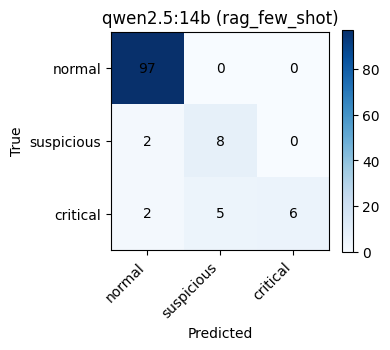

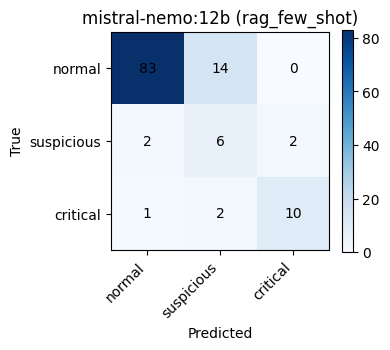

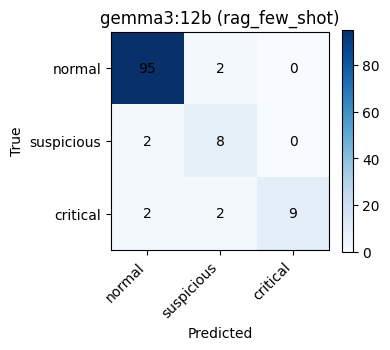

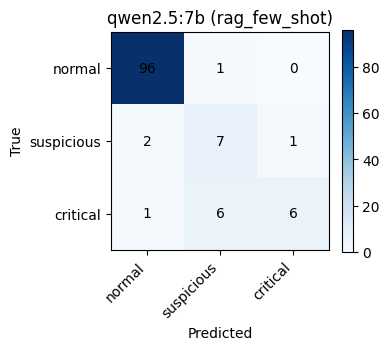

In [19]:
def plot_confusion(parsed, model, mode, labels=("normal", "suspicious", "critical")):
    grp = parsed[(parsed["model"] == model) & (parsed["mode"] == mode)].dropna(subset=["pred"])
    if grp.empty:
        return
    cm = confusion_matrix(grp["gold"], grp["pred"], labels=list(labels))
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("%s (%s)" % (model, mode))
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    safe = model.replace(":", "_").replace("/", "_")
    fig.savefig(RESULTS_DIR / ("cm_%s_%s.png" % (safe, mode)), dpi=150)
    plt.show()


strategies_present = list(parsed_results["mode"].unique())
focus_strategy = "rag_few_shot" if "rag_few_shot" in strategies_present else (
    strategies_present[0] if strategies_present else "zero_shot")
for m in parsed_results["model"].unique():
    plot_confusion(parsed_results, m, focus_strategy)

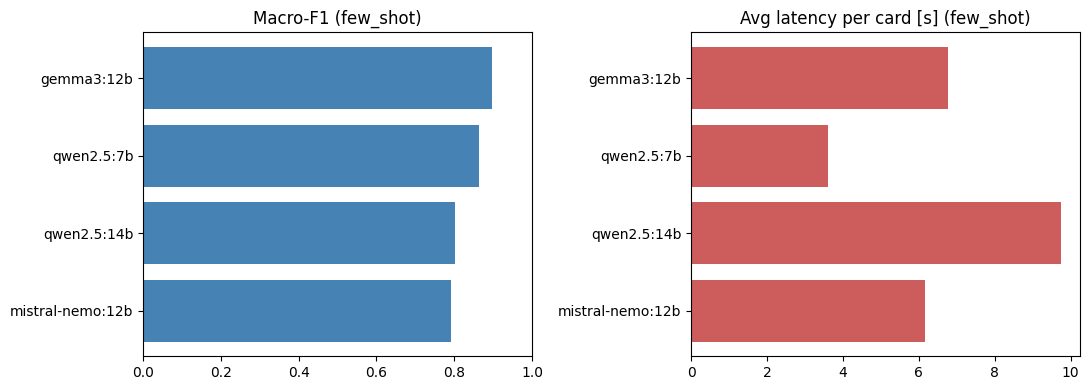

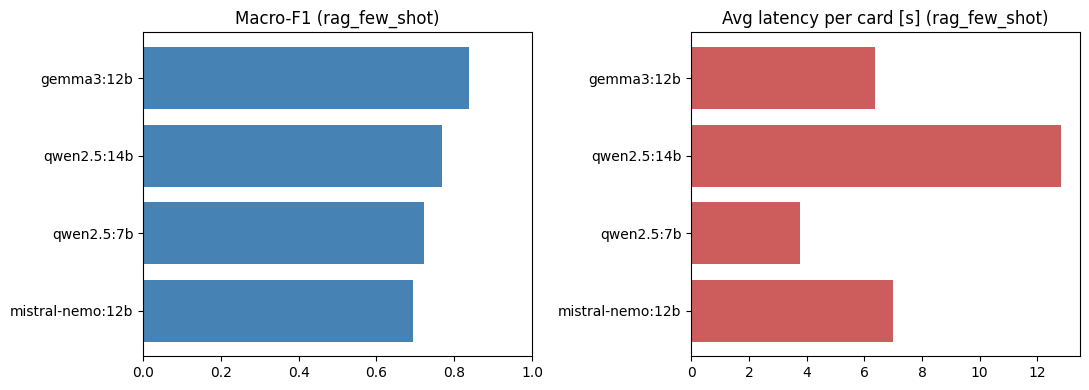

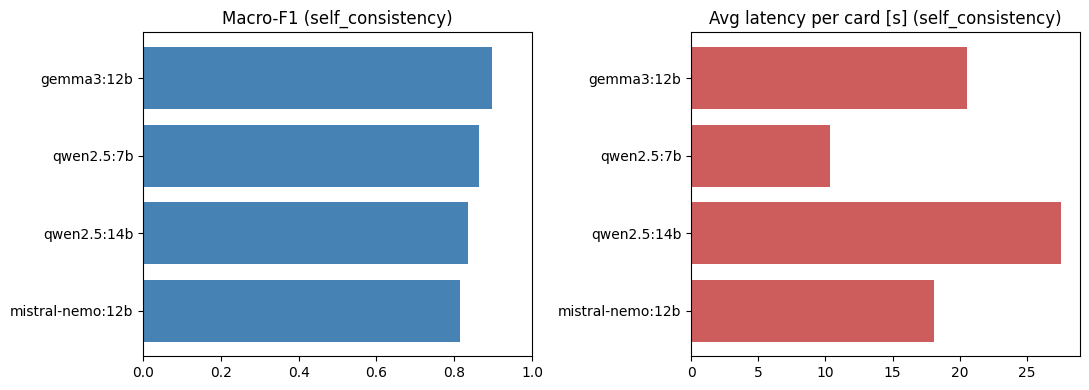

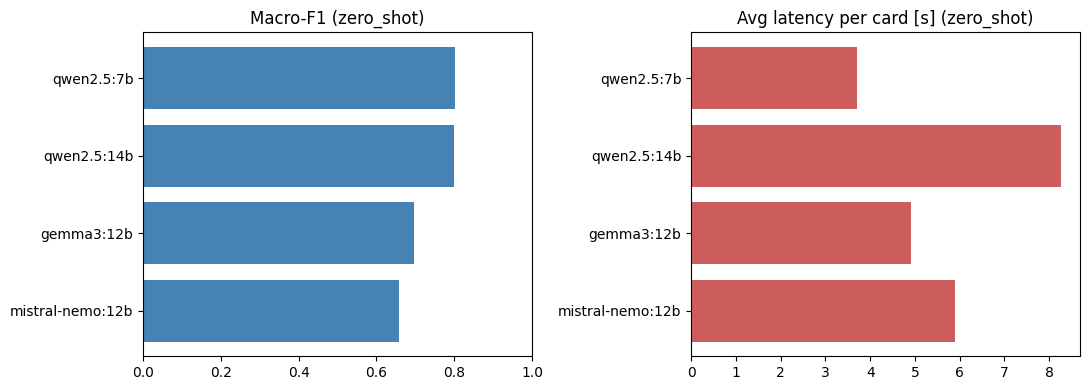

In [20]:
def plot_metric_bars(metrics, mode):
    sub = metrics[metrics["mode"] == mode].sort_values("macro_f1")
    if sub.empty:
        return
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].barh(sub["model"], sub["macro_f1"], color="steelblue")
    ax[0].set_xlim(0, 1)
    ax[0].set_title("Macro-F1 (%s)" % mode)
    ax[1].barh(sub["model"], sub["avg_latency_s"], color="indianred")
    ax[1].set_title("Avg latency per card [s] (%s)" % mode)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / ("comparison_%s.png" % mode), dpi=150)
    plt.show()


for mode in llm_metrics["mode"].unique():
    plot_metric_bars(llm_metrics, mode)

In [21]:
llm_view = llm_metrics[["model", "mode", "accuracy", "macro_precision", "macro_recall", "macro_f1"]]
combined = pd.concat([baseline_results.assign(mode="classical"), llm_view], ignore_index=True, sort=False)
combined = combined[["model", "mode", "accuracy", "macro_precision", "macro_recall", "macro_f1"]]
combined.to_csv(RESULTS_DIR / "combined_results.csv", index=False)
combined

,model,mode,accuracy,macro_precision,macro_recall,macro_f1
0,RandomForest,classical,0.956912,0.973707,0.863862,0.911863
1,LogisticRegression,classical,0.838139,0.673466,0.807005,0.720641
2,RuleBased,classical,0.380266,0.436452,0.635251,0.369187
3,gemma3:12b,few_shot,0.958333,0.949762,0.856410,0.897156
4,qwen2.5:7b,few_shot,0.950000,0.914829,0.823077,0.863636
5,qwen2.5:14b,few_shot,0.933333,0.875688,0.779487,0.802357
6,mistral-nemo:12b,few_shot,0.933333,0.854320,0.756410,0.791343
7,gemma3:12b,rag_few_shot,0.933333,0.875421,0.823896,0.838281
8,qwen2.5:14b,rag_few_shot,0.925000,0.858594,0.753846,0.769010
9,qwen2.5:7b,rag_few_shot,0.908333,0.775613,0.717076,0.720975


In [22]:
def export_annotation_sheet(parsed, raw, path, per_group=10):
    merged = parsed.merge(raw[["model", "mode", "idx", "raw"]], on=["model", "mode", "idx"], how="left")
    rows = []
    for (model, mode), grp in merged.groupby(["model", "mode"]):
        for _, r in grp.head(per_group).iterrows():
            parsed_json = extract_json(r["raw"]) or {}
            rows.append({
                "model": model,
                "mode": mode,
                "idx": r["idx"],
                "card": CARD_BY_IDX.get(r["idx"], ""),
                "main_reason": parsed_json.get("main_reason", ""),
                "operator_summary": parsed_json.get("operator_summary", ""),
                "recommended_verification": parsed_json.get("recommended_verification", ""),
                "usefulness_1_5": "",
                "faithfulness_1_5": "",
            })
    sheet = pd.DataFrame(rows)
    sheet.to_csv(path, index=False)
    return sheet


annotation_sheet = export_annotation_sheet(parsed_results, raw_results, RESULTS_DIR / "explanation_annotation.csv")
annotation_sheet.shape

(160, 9)

## Notes and limitations

- The three-class severity target is a proxy derived from the binary attack label and the deviation
  magnitude, rather than from expert severity annotations.
- The network/protocol indicators are summarized as a placeholder; this pipeline uses the process view, so
  `affected_layer` is inferred from process evidence.
- RAG exemplar answers are templated from the window severity and dominant deviations, so they teach the
  JSON format and the target class rather than nuanced human-written explanations.
- The hallucination metric is a lexical proxy, complemented by the manual review on the exported annotation
  sheet (`results/explanation_annotation.csv`).

In [23]:
import math
import pandas as pd
from pathlib import Path

def wilson_ci(p, n, z=1.96):
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z / denom) * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return max(0.0, center - half), min(1.0, center + half)

results_dir = RESULTS_DIR if "RESULTS_DIR" in globals() else Path("../results")
ci = pd.read_csv(results_dir / "llm_metrics.csv")
ci[["acc_ci_low", "acc_ci_high"]] = [wilson_ci(a, n) for a, n in zip(ci["accuracy"], ci["n"])]
ci = ci[["model", "mode", "accuracy", "acc_ci_low", "acc_ci_high"]].sort_values("accuracy", ascending=False)
ci.to_csv(results_dir / "llm_metrics_ci.csv", index=False)
ci


,model,mode,accuracy,acc_ci_low,acc_ci_high
0,gemma3:12b,few_shot,0.958333,0.906158,0.982074
8,gemma3:12b,self_consistency,0.958333,0.906158,0.982074
9,qwen2.5:7b,self_consistency,0.950000,0.895196,0.976886
1,qwen2.5:7b,few_shot,0.950000,0.895196,0.976886
10,qwen2.5:14b,self_consistency,0.941667,0.884473,0.971459
11,mistral-nemo:12b,self_consistency,0.941176,0.883848,0.971134
2,qwen2.5:14b,few_shot,0.933333,0.873947,0.965835
3,mistral-nemo:12b,few_shot,0.933333,0.873947,0.965835
12,qwen2.5:7b,zero_shot,0.933333,0.873947,0.965835
13,qwen2.5:14b,zero_shot,0.933333,0.873947,0.965835
